<div align="center">

<img src="CLUSTERING.png" width="700">
</div>

### WORK FLOW
1. Data Collection
   - The world military power dataset was imported from an Excel file.

2. Data Understanding
   - The dataset structure, columns, and data types were examined.
   - Missing and duplicated values were checked.

3. Data Cleaning and Preprocessing
   - Unnecessary columns were removed.
   - Country names and military indicators were organized.
   - Numerical values were converted into proper numeric format.
   - Missing values were filled.
   - Features were standardized using StandardScaler.

4. Exploratory Data Analysis (EDA)
   - Military strength indicators were analyzed.
   - Correlations and distributions were explored.

5. K-Means Clustering
   - K-Means algorithm was applied.
   - Elbow Method and Silhouette Score were used to determine the optimal cluster number.
   - Countries were grouped according to military strength.

6. Hierarchical Clustering
   - Agglomerative Clustering was implemented.
   - Dendrogram analysis was used to visualize hierarchical relationships between countries.

7. DBSCAN Clustering
   - Density-based clustering was applied.
   - Outlier countries and density-based groups were identified.

8. PCA Visualization
   - Principal Component Analysis (PCA) reduced the dataset into 2 dimensions.
   - Clusters were visualized on scatter plots.

9. Cluster Interpretation
   - Super powers, regional powers, and lower military capacity countries were identified.
   - Cluster characteristics were analyzed and interpreted.

10. Conclusion
   - Clustering algorithms successfully identified meaningful military power groups among countries.

In [2]:
import pandas as pd

In [3]:
import warnings 
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("World military power.xlsx")

In [6]:
df.head()

,2020 ranking,Unnamed: 1,Airforce Strength,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 50,Unnamed: 51,Geography,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
0,Military Strength,Military Strength Power Index,Aircraft Strength,Aircraft Strength value,Fighter/Interceptor Strength,Fighter/Interceptor Strength value,Attack Aircraft Strength,Attack Aircraft Strength value,Transport Aircraft Fleet Strength,Transport Aircraft Fleet Strength value,...,Total Population,Total Population value,Total Square Land Area,Total Square Land Area value,Total Coastline Coverage,Total Coastline Coverage value,Total Waterway Coverage,Total Waterway Coverage value,Total Border Coverage,Total Border Coverage value
1,Afghanistan,1.3444,Afghanistan,260,Afghanistan,0,Afghanistan,25,Afghanistan,30,...,Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan,5987
2,Albania,2.3137,Albania,19,Albania,0,Albania,0,Albania,0,...,Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania,691
3,Algeria,0.4659,Algeria,551,Algeria,103,Algeria,22,Algeria,59,...,Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria,6734
4,Angola,0.8379,Angola,295,Angola,72,Angola,18,Angola,30,...,Angola,"3,03,55,880",Angola,"12,46,700",Angola,1600,Angola,1300,Angola,5369


In [7]:
df.sample()

,2020 ranking,Unnamed: 1,Airforce Strength,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 50,Unnamed: 51,Geography,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
94,Paraguay,2.1898,Paraguay,33,Paraguay,0,Paraguay,0,Paraguay,6,...,Paraguay,"70,25,763",Paraguay,"4,06,752",NaN,NaN,Paraguay,3100,Paraguay,4655


In [9]:
import pandas as pd

df_raw = pd.read_excel("World military power.xlsx", header=None)

columns = df_raw.iloc[1]

clean_df = df_raw.iloc[2:].copy()

clean_df.columns = columns

clean_df = clean_df.reset_index(drop=True)

In [10]:
X = clean_df.drop(["Country", "Cluster", "Power_Level"], axis=1, errors="ignore")

X.head()

1,Military Strength,Military Strength Power Index,Aircraft Strength,Aircraft Strength value,Fighter/Interceptor Strength,Fighter/Interceptor Strength value,Attack Aircraft Strength,Attack Aircraft Strength value,Transport Aircraft Fleet Strength,Transport Aircraft Fleet Strength value,...,Total Population,Total Population value,Total Square Land Area,Total Square Land Area value,Total Coastline Coverage,Total Coastline Coverage value,Total Waterway Coverage,Total Waterway Coverage value,Total Border Coverage,Total Border Coverage value
0,Afghanistan,1.3444,Afghanistan,260,Afghanistan,0,Afghanistan,25,Afghanistan,30,...,Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan,5987
1,Albania,2.3137,Albania,19,Albania,0,Albania,0,Albania,0,...,Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania,691
2,Algeria,0.4659,Algeria,551,Algeria,103,Algeria,22,Algeria,59,...,Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria,6734
3,Angola,0.8379,Angola,295,Angola,72,Angola,18,Angola,30,...,Angola,"3,03,55,880",Angola,"12,46,700",Angola,1600,Angola,1300,Angola,5369
4,Argentina,0.6521,Argentina,227,Argentina,24,Argentina,7,Argentina,9,...,Argentina,"4,46,94,198",Argentina,"27,80,400",Argentina,4989,Argentina,11000,Argentina,11968


In [11]:
clean_df = clean_df.rename(
    columns={"Military Strength": "Country"}
)

In [12]:
country_like_cols = [

    col for col in clean_df.columns

    if "value" not in str(col)
    and "Index" not in str(col)
    and col != "Country"
]

clean_df = clean_df.drop(columns=country_like_cols)

In [13]:
for col in clean_df.columns:

    if col != "Country":

        clean_df[col] = (
            clean_df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
        )

        clean_df[col] = pd.to_numeric(
            clean_df[col],
            errors="coerce"        )

In [14]:
clean_df = clean_df.fillna(clean_df.mean(numeric_only=True))

In [15]:
X = clean_df.drop("Country", axis=1)

X.head()

1,Military Strength Power Index,Aircraft Strength value,Fighter/Interceptor Strength value,Attack Aircraft Strength value,Transport Aircraft Fleet Strength value,Trainer Aircraft Fleet value,Helicopter Fleet Strength value,Attack Helicopter Fleet Strength value,Tank Strength value,AFV/APC Strength value,...,Airport Totals value,Oil Production value,Oil Consumption value,Proven Oil Reserves value,Available Manpower value,Total Population value,Total Square Land Area value,Total Coastline Coverage value,Total Waterway Coverage value,Total Border Coverage value
0,1.3444,260,0,25,30,0,187,0,0,1062,...,43,0,5500,0,14325743,34940837,652230,0.0,1200,5987.0
1,2.3137,19,0,0,0,0,19,0,0,467,...,4,16000,42500,168300000,1519438,3057220,28748,362.0,41,691.0
2,0.4659,551,103,22,59,87,257,45,880,7361,...,157,1306000,325000,12200000000,20741263,41657488,2381741,998.0,0,6734.0
3,0.8379,295,72,18,30,47,126,15,379,595,...,176,1666000,82300,8273000000,6244205,30355880,1246700,1600.0,1300,5369.0
4,0.6521,227,24,7,9,64,100,0,370,739,...,1138,479400,685000,2185000000,20179430,44694198,2780400,4989.0,11000,11968.0


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    print(f"K={k} | Silhouette Score: {score:.4f}")

K=2 | Silhouette Score: 0.8534
K=3 | Silhouette Score: 0.5854
K=4 | Silhouette Score: 0.5886
K=5 | Silhouette Score: 0.4805
K=6 | Silhouette Score: 0.5062
K=7 | Silhouette Score: 0.4641
K=8 | Silhouette Score: 0.4076
K=9 | Silhouette Score: 0.4144
K=10 | Silhouette Score: 0.2875


In [19]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = range(2, 11)[scores.index(max(scores))]

print("Best K:", best_k)
print("Best Silhouette Score:", max(scores))

Best K: 2
Best Silhouette Score: 0.8534052260274093


In [20]:
kmeans = KMeans(n_clusters=best_k, random_state=42)

clean_df["Cluster"] = kmeans.fit_predict(X_scaled)

clean_df[["Country", "Cluster"]].head()

1,Country,Cluster
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,1
4,Argentina,1


In [21]:
for cluster in sorted(clean_df["Cluster"].unique()):
    print(f"\nCLUSTER {cluster}")
    print(clean_df[clean_df["Cluster"] == cluster]["Country"].values)


CLUSTER 0
['China' 'Russia' 'United States']

CLUSTER 1
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus'
 'Belgium' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Burkina Faso' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'Colombia' 'Croatia' 'Cuba'
 'Czechia' 'Democratic Republic of the Congo' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Ethiopia'
 'Finland' 'France' 'Gabon' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Guatemala' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' 'Israel' 'Italy' 'Ivory Coast' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kuwait' 'Kyrgyzstan' 'Laos' 'Latvia' 'Lebanon' 'Liberia' 'Libya'
 'Lithuania' 'Madagascar' 'Malaysia' 'Mali' 'Mauritania' 'Mexico'
 'Moldova' 'Mongolia' 'Montenegro' 'Morocco' 'Mozambique' 'Myanmar'
 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua' 

In [22]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42)

clean_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [23]:
for cluster in sorted(clean_df["Cluster"].unique()):

    print(f"\nCLUSTER {cluster}\n")

    print(
        clean_df[
            clean_df["Cluster"] == cluster
        ]["Country"].values)


CLUSTER 0

['Egypt' 'India' 'Iran' 'North Korea' 'Saudi Arabia' 'South Korea']

CLUSTER 1

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Bulgaria'
 'Burkina Faso' 'Cambodia' 'Cameroon' 'Central African Republic' 'Chad'
 'Chile' 'Colombia' 'Croatia' 'Cuba' 'Czechia'
 'Democratic Republic of the Congo' 'Denmark' 'Dominican Republic'
 'Ecuador' 'El Salvador' 'Estonia' 'Ethiopia' 'Finland' 'Gabon' 'Georgia'
 'Ghana' 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Iraq' 'Ireland'
 'Israel' 'Ivory Coast' 'Jordan' 'Kazakhstan' 'Kenya' 'Kuwait'
 'Kyrgyzstan' 'Laos' 'Latvia' 'Lebanon' 'Liberia' 'Libya' 'Lithuania'
 'Madagascar' 'Malaysia' 'Mali' 'Mauritania' 'Mexico' 'Moldova' 'Mongolia'
 'Montenegro' 'Morocco' 'Mozambique' 'Myanmar' 'Namibia' 'Nepal'
 'Netherlands' 'New Zealand' 'Nicaragua' 'Niger' 'Nigeria'
 'North Macedonia' 'Norway' 'Oman' 'Panama' 'Par

In [24]:
cluster_power = (clean_df
    .groupby("Cluster")["Military Strength Power Index"]
    .mean().sort_values())
cluster_power

Cluster
3    0.060600
2    0.068600
0    0.221283
4    0.242967
1    1.684938
Name: Military Strength Power Index, dtype: float64

In [25]:
power_labels = {
    cluster_power.index[0]: "1 - Very Strong",
    cluster_power.index[1]: "2 - Strong",
    cluster_power.index[2]: "3 - Medium Strong",
    cluster_power.index[3]: "4 - Medium",
    cluster_power.index[4]: "5 - Weak"}

clean_df["Power_Level"] = clean_df["Cluster"].map(power_labels)

In [26]:
clean_df[[
    "Country",
    "Cluster",
    "Power_Level",
    "Military Strength Power Index"]].sort_values("Military Strength Power Index")

1,Country,Cluster,Power_Level,Military Strength Power Index
130,United States,3,1 - Very Strong,0.0606
101,Russia,2,2 - Strong,0.0681
26,China,2,2 - Strong,0.0691
49,India,0,3 - Medium Strong,0.0953
57,Japan,4,4 - Medium,0.1501
...,...,...,...,...
104,Sierra Leone,1,5 - Weak,4.2063
115,Suriname,1,5 - Weak,4.6042
108,Somalia,1,5 - Weak,4.6404
66,Liberia,1,5 - Weak,5.5737


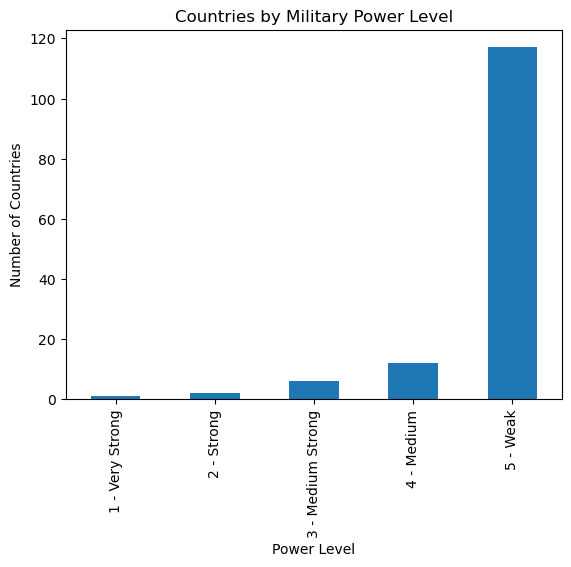

In [27]:
clean_df["Power_Level"].value_counts().sort_index().plot(kind="bar")

plt.title("Countries by Military Power Level")
plt.xlabel("Power Level")
plt.ylabel("Number of Countries")
plt.show()

In [28]:
clean_df[[
    "Country",
    "Power_Level",
    "Military Strength Power Index"
]].sort_values(
    by="Military Strength Power Index")

1,Country,Power_Level,Military Strength Power Index
130,United States,1 - Very Strong,0.0606
101,Russia,2 - Strong,0.0681
26,China,2 - Strong,0.0691
49,India,3 - Medium Strong,0.0953
57,Japan,4 - Medium,0.1501
...,...,...,...
104,Sierra Leone,5 - Weak,4.2063
115,Suriname,5 - Weak,4.6042
108,Somalia,5 - Weak,4.6404
66,Liberia,5 - Weak,5.5737


In [29]:
clean_df[
    clean_df["Power_Level"] == "1 - Very Strong"][["Country","Military Strength Power Index"]]

1,Country,Military Strength Power Index
130,United States,0.0606


In [31]:
for level in [
    "1 - Very Strong",
    "2 - Strong",
    "3 - Medium Strong",
    "4 - Medium",
    "5 - Weak"]:

    print(f"\n {level}\n")

    countries = clean_df[
        clean_df["Power_Level"] == level]["Country"].values
    print(", ".join(countries))


 1 - Very Strong

United States

 2 - Strong

China, Russia

 3 - Medium Strong

Egypt, India, Iran, North Korea, Saudi Arabia, South Korea

 4 - Medium

Australia, Brazil, Canada, France, Germany, Indonesia, Italy, Japan, Pakistan, Taiwan, Turkey, United Kingdom

 5 - Weak

Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Austria, Azerbaijan, Bahrain, Bangladesh, Belarus, Belgium, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Bulgaria, Burkina Faso, Cambodia, Cameroon, Central African Republic, Chad, Chile, Colombia, Croatia, Cuba, Czechia, Democratic Republic of the Congo, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Ethiopia, Finland, Gabon, Georgia, Ghana, Greece, Guatemala, Honduras, Hungary, Iraq, Ireland, Israel, Ivory Coast, Jordan, Kazakhstan, Kenya, Kuwait, Kyrgyzstan, Laos, Latvia, Lebanon, Liberia, Libya, Lithuania, Madagascar, Malaysia, Mali, Mauritania, Mexico, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Namibia, Nepal, Neth

In [32]:
!pip install yellowbrick

In [33]:
from yellowbrick.cluster import KElbowVisualizer

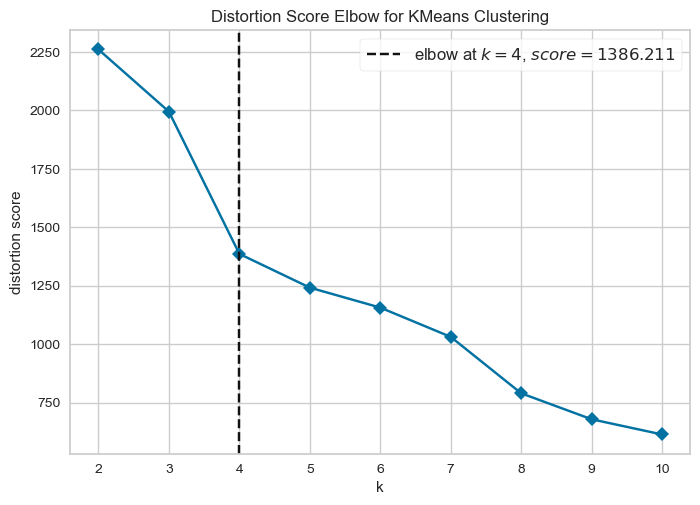

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [34]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2, 11),
    metric="distortion",
    timings=False
)

visualizer.fit(X_scaled)
visualizer.show()

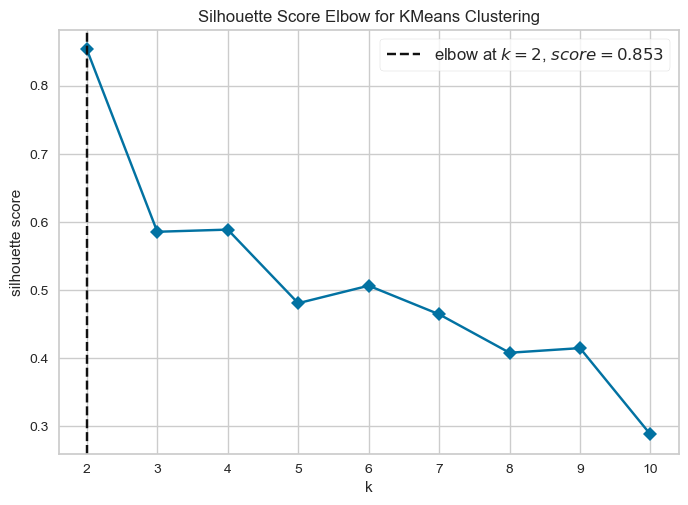

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [35]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 11),
    metric="silhouette",
    timings=False)

visualizer.fit(X_scaled)
visualizer.show()

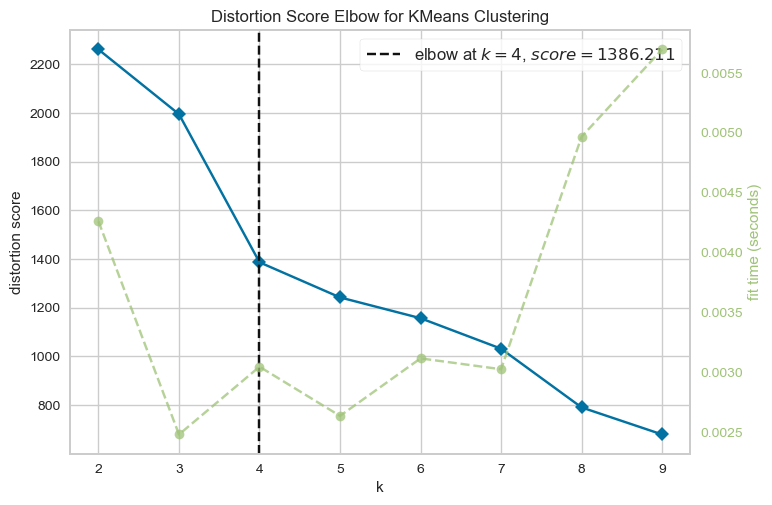

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

vis = KElbowVisualizer(
    KMeans(random_state=42),
    k=(2,10))

vis.fit(X_scaled)

vis.show()

In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42)

clean_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [38]:
cluster_power = (
    clean_df
    .groupby("Cluster")["Military Strength Power Index"]
    .mean()
    .sort_values())

cluster_power

Cluster
3    0.060600
2    0.068600
0    0.221738
1    1.571709
Name: Military Strength Power Index, dtype: float64

In [39]:
power_labels = {
    cluster_power.index[0]: "1 - Super Power",
    cluster_power.index[1]: "2 - Great Power",
    cluster_power.index[2]: "3 - Regional Power",
    cluster_power.index[3]: "4 - Medium / Low Power"}

clean_df["Power_Level"] = clean_df["Cluster"].map(power_labels)

In [40]:
for level in [
    "1 - Super Power",
    "2 - Great Power",
    "3 - Regional Power",
    "4 - Medium / Low Power"]:

    print("\n" + "="*60)
    print(level)
    print("="*60)

    countries = clean_df[
        clean_df["Power_Level"] == level
    ]["Country"].tolist()

    print(", ".join(countries))


1 - Super Power
United States

2 - Great Power
China, Russia

3 - Regional Power
Egypt, India, Iran, North Korea, Pakistan, Saudi Arabia, South Korea, Turkey

4 - Medium / Low Power
Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahrain, Bangladesh, Belarus, Belgium, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Burkina Faso, Cambodia, Cameroon, Canada, Central African Republic, Chad, Chile, Colombia, Croatia, Cuba, Czechia, Democratic Republic of the Congo, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Ethiopia, Finland, France, Gabon, Georgia, Germany, Ghana, Greece, Guatemala, Honduras, Hungary, Indonesia, Iraq, Ireland, Israel, Italy, Ivory Coast, Japan, Jordan, Kazakhstan, Kenya, Kuwait, Kyrgyzstan, Laos, Latvia, Lebanon, Liberia, Libya, Lithuania, Madagascar, Malaysia, Mali, Mauritania, Mexico, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Namibia, Nepal, Netherlands, New Zealand, Nic

### Hierarchical Clustering

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [43]:
linked = linkage(
    X_scaled,
    method="ward")

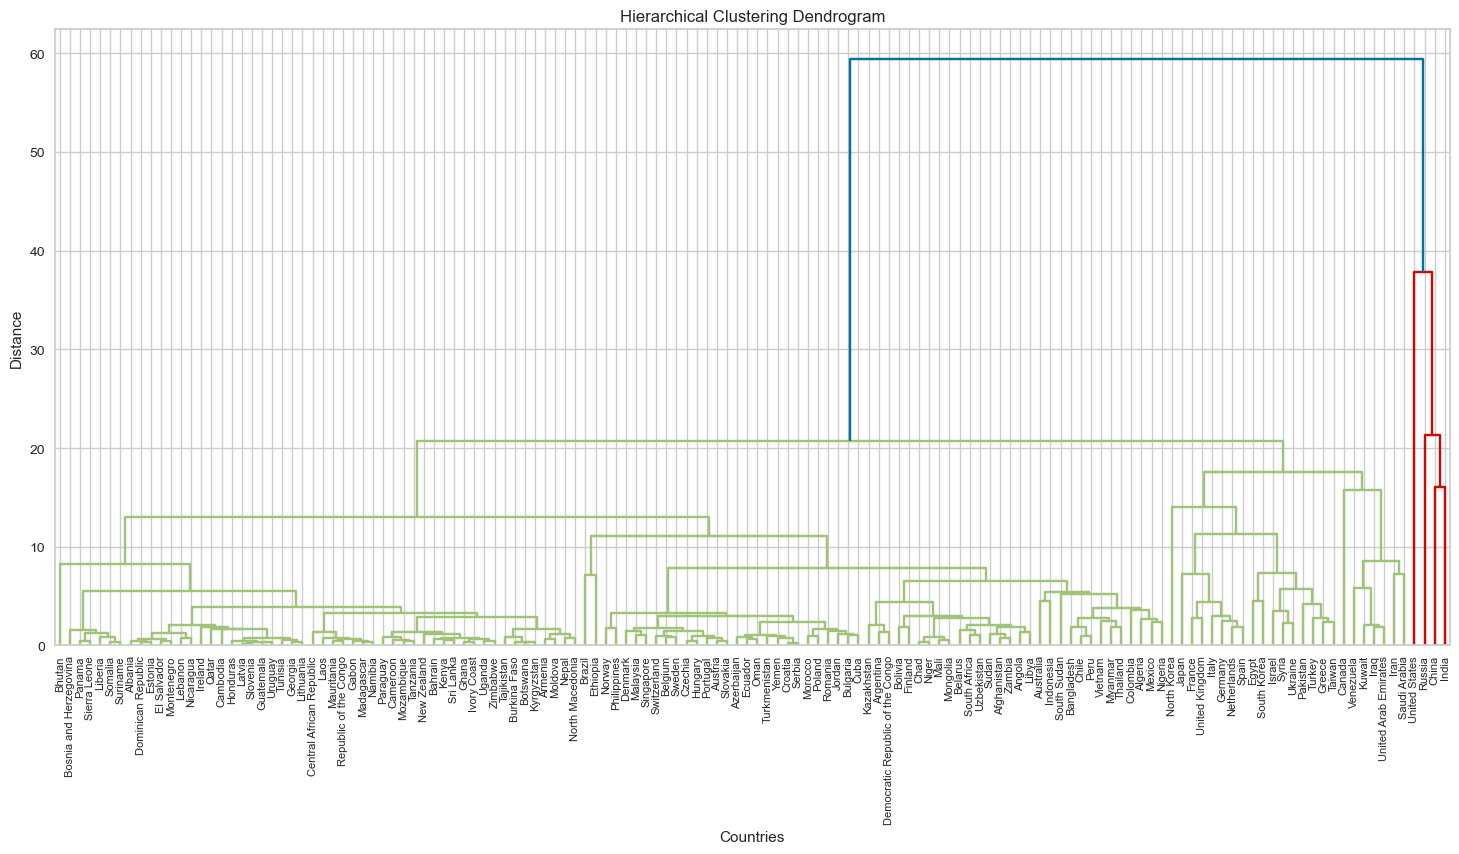

In [44]:
plt.figure(figsize=(18,8))

dendrogram(
    linked,
    labels=clean_df["Country"].values,
    leaf_rotation=90,
    leaf_font_size=8)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Countries")
plt.ylabel("Distance")

plt.show()

In [45]:
from sklearn.cluster import AgglomerativeClustering

In [82]:
agg_clustering = AgglomerativeClustering(n_clusters=5)

clean_df["Agg_Cluster"] = agg_clustering.fit_predict(x_scaled)

cluster_power = (
    clean_df
    .groupby("Agg_Cluster")["Military Strength Power Index"]
    .mean()
    .sort_values())

print(cluster_power)


Agg_Cluster
2    0.060600
3    0.068100
1    0.082200
0    0.421854
4    1.737829
Name: Military Strength Power Index, dtype: float64


In [83]:
power_labels = {
    cluster_power.index[0]: "1 - Super Power",
    cluster_power.index[1]: "2 - Great Power",
    cluster_power.index[2]: "3 - Regional Power",
    cluster_power.index[3]: "4 - Medium Power",
    cluster_power.index[4]: "5 - Lower Power"}

clean_df["Agg_Power_Level"] = clean_df["Agg_Cluster"].map(power_labels)

In [85]:
for level in [
    "1 - Super Power",
    "2 - Great Power",
    "3 - Regional Power",
    "4 - Medium Power",
    "5 - Lower Power"
]:

    print("\n" + "="*60)
    print(level)
    print("="*60)

    countries = clean_df[
        clean_df["Agg_Power_Level"] == level
    ]["Country"].tolist()

    print(", ".join(countries))


1 - Super Power
United States

2 - Great Power
Russia

3 - Regional Power
China, India

4 - Medium Power
Canada, Egypt, France, Germany, Greece, Iran, Iraq, Israel, Italy, Japan, Kuwait, Netherlands, North Korea, Pakistan, Saudi Arabia, South Korea, Spain, Syria, Taiwan, Turkey, Ukraine, United Arab Emirates, United Kingdom, Venezuela

5 - Lower Power
Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahrain, Bangladesh, Belarus, Belgium, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, Bulgaria, Burkina Faso, Cambodia, Cameroon, Central African Republic, Chad, Chile, Colombia, Croatia, Cuba, Czechia, Democratic Republic of the Congo, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Ethiopia, Finland, Gabon, Georgia, Ghana, Guatemala, Honduras, Hungary, Indonesia, Ireland, Ivory Coast, Jordan, Kazakhstan, Kenya, Kyrgyzstan, Laos, Latvia, Lebanon, Liberia, Libya, Lithuania, Madagascar, Malaysia, Mali, Mauritania, Mexico, Mol

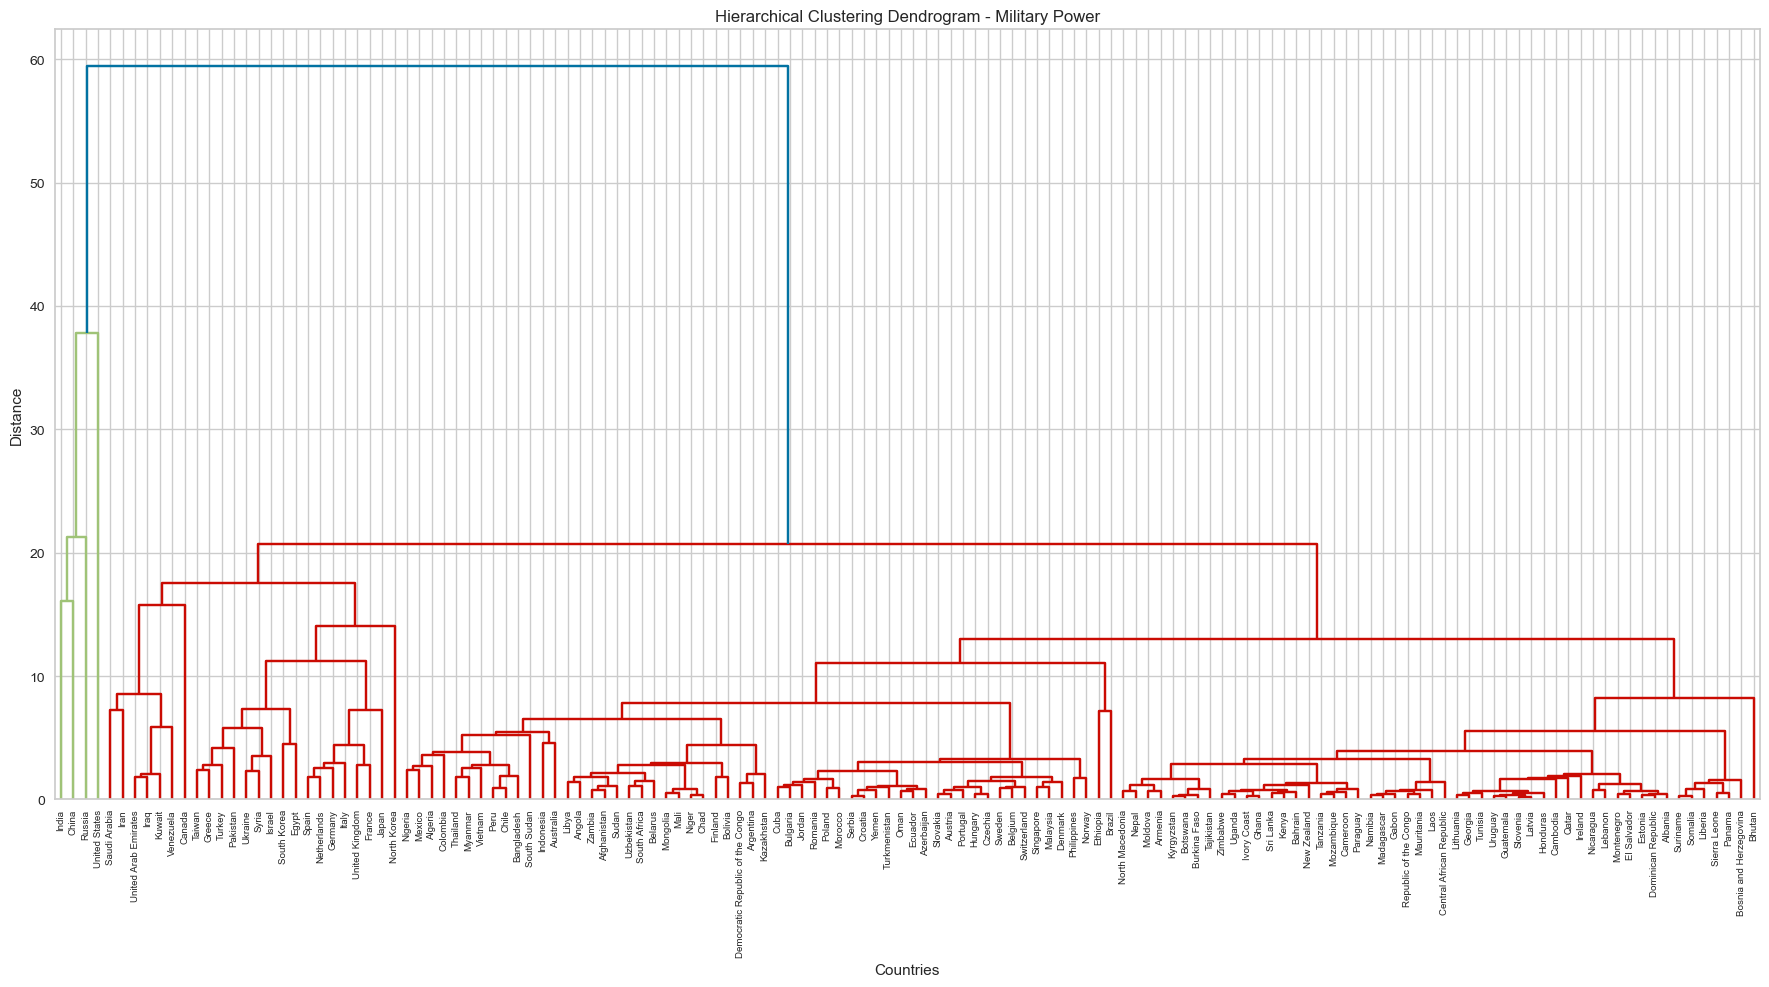

In [84]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical clustering - kendi projemizin verisi
linked = linkage(X_scaled, method="ward")

# Dendrogram
plt.figure(figsize=(22, 10))

dendrogram(
    linked,
    labels=clean_df["Country"].values,
    orientation="top",
    distance_sort="descending",
    leaf_rotation=90,
    leaf_font_size=7,
    show_leaf_counts=True)

plt.title("Hierarchical Clustering Dendrogram - Military Power")
plt.xlabel("Countries")
plt.ylabel("Distance")

plt.show()

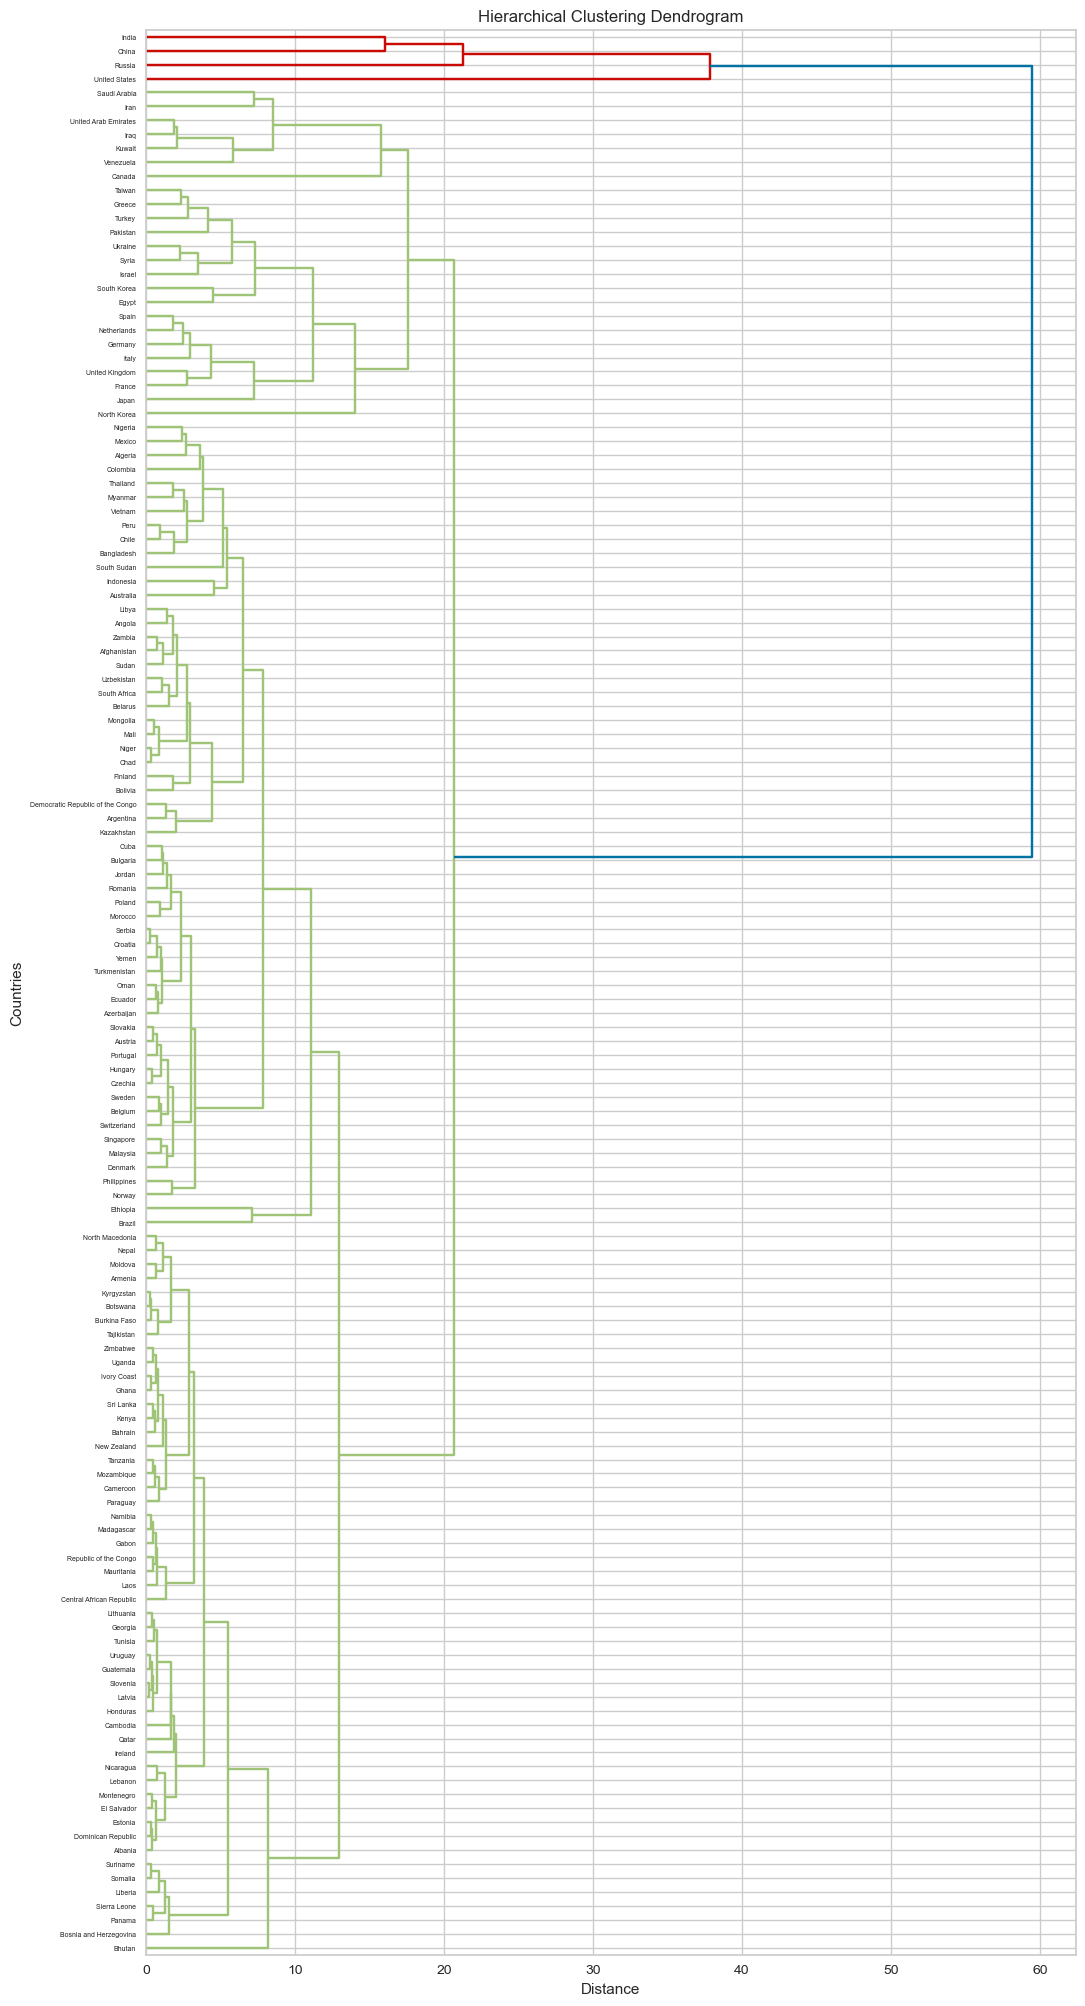

In [69]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Hierarchical Clustering
Z = linkage(X_scaled, method='ward')

# Dendrogram
plt.figure(figsize=(12,25))

dendrogram(
    Z,
    labels=clean_df["Country"].values,
    orientation='right')

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Distance")
plt.ylabel("Countries")

plt.show()

In [70]:
X = clean_df.drop(
    ["Country", "Cluster", "Power_Level", "HC_Cluster"],
    axis=1,
    errors="ignore")

X = X.fillna(X.mean())

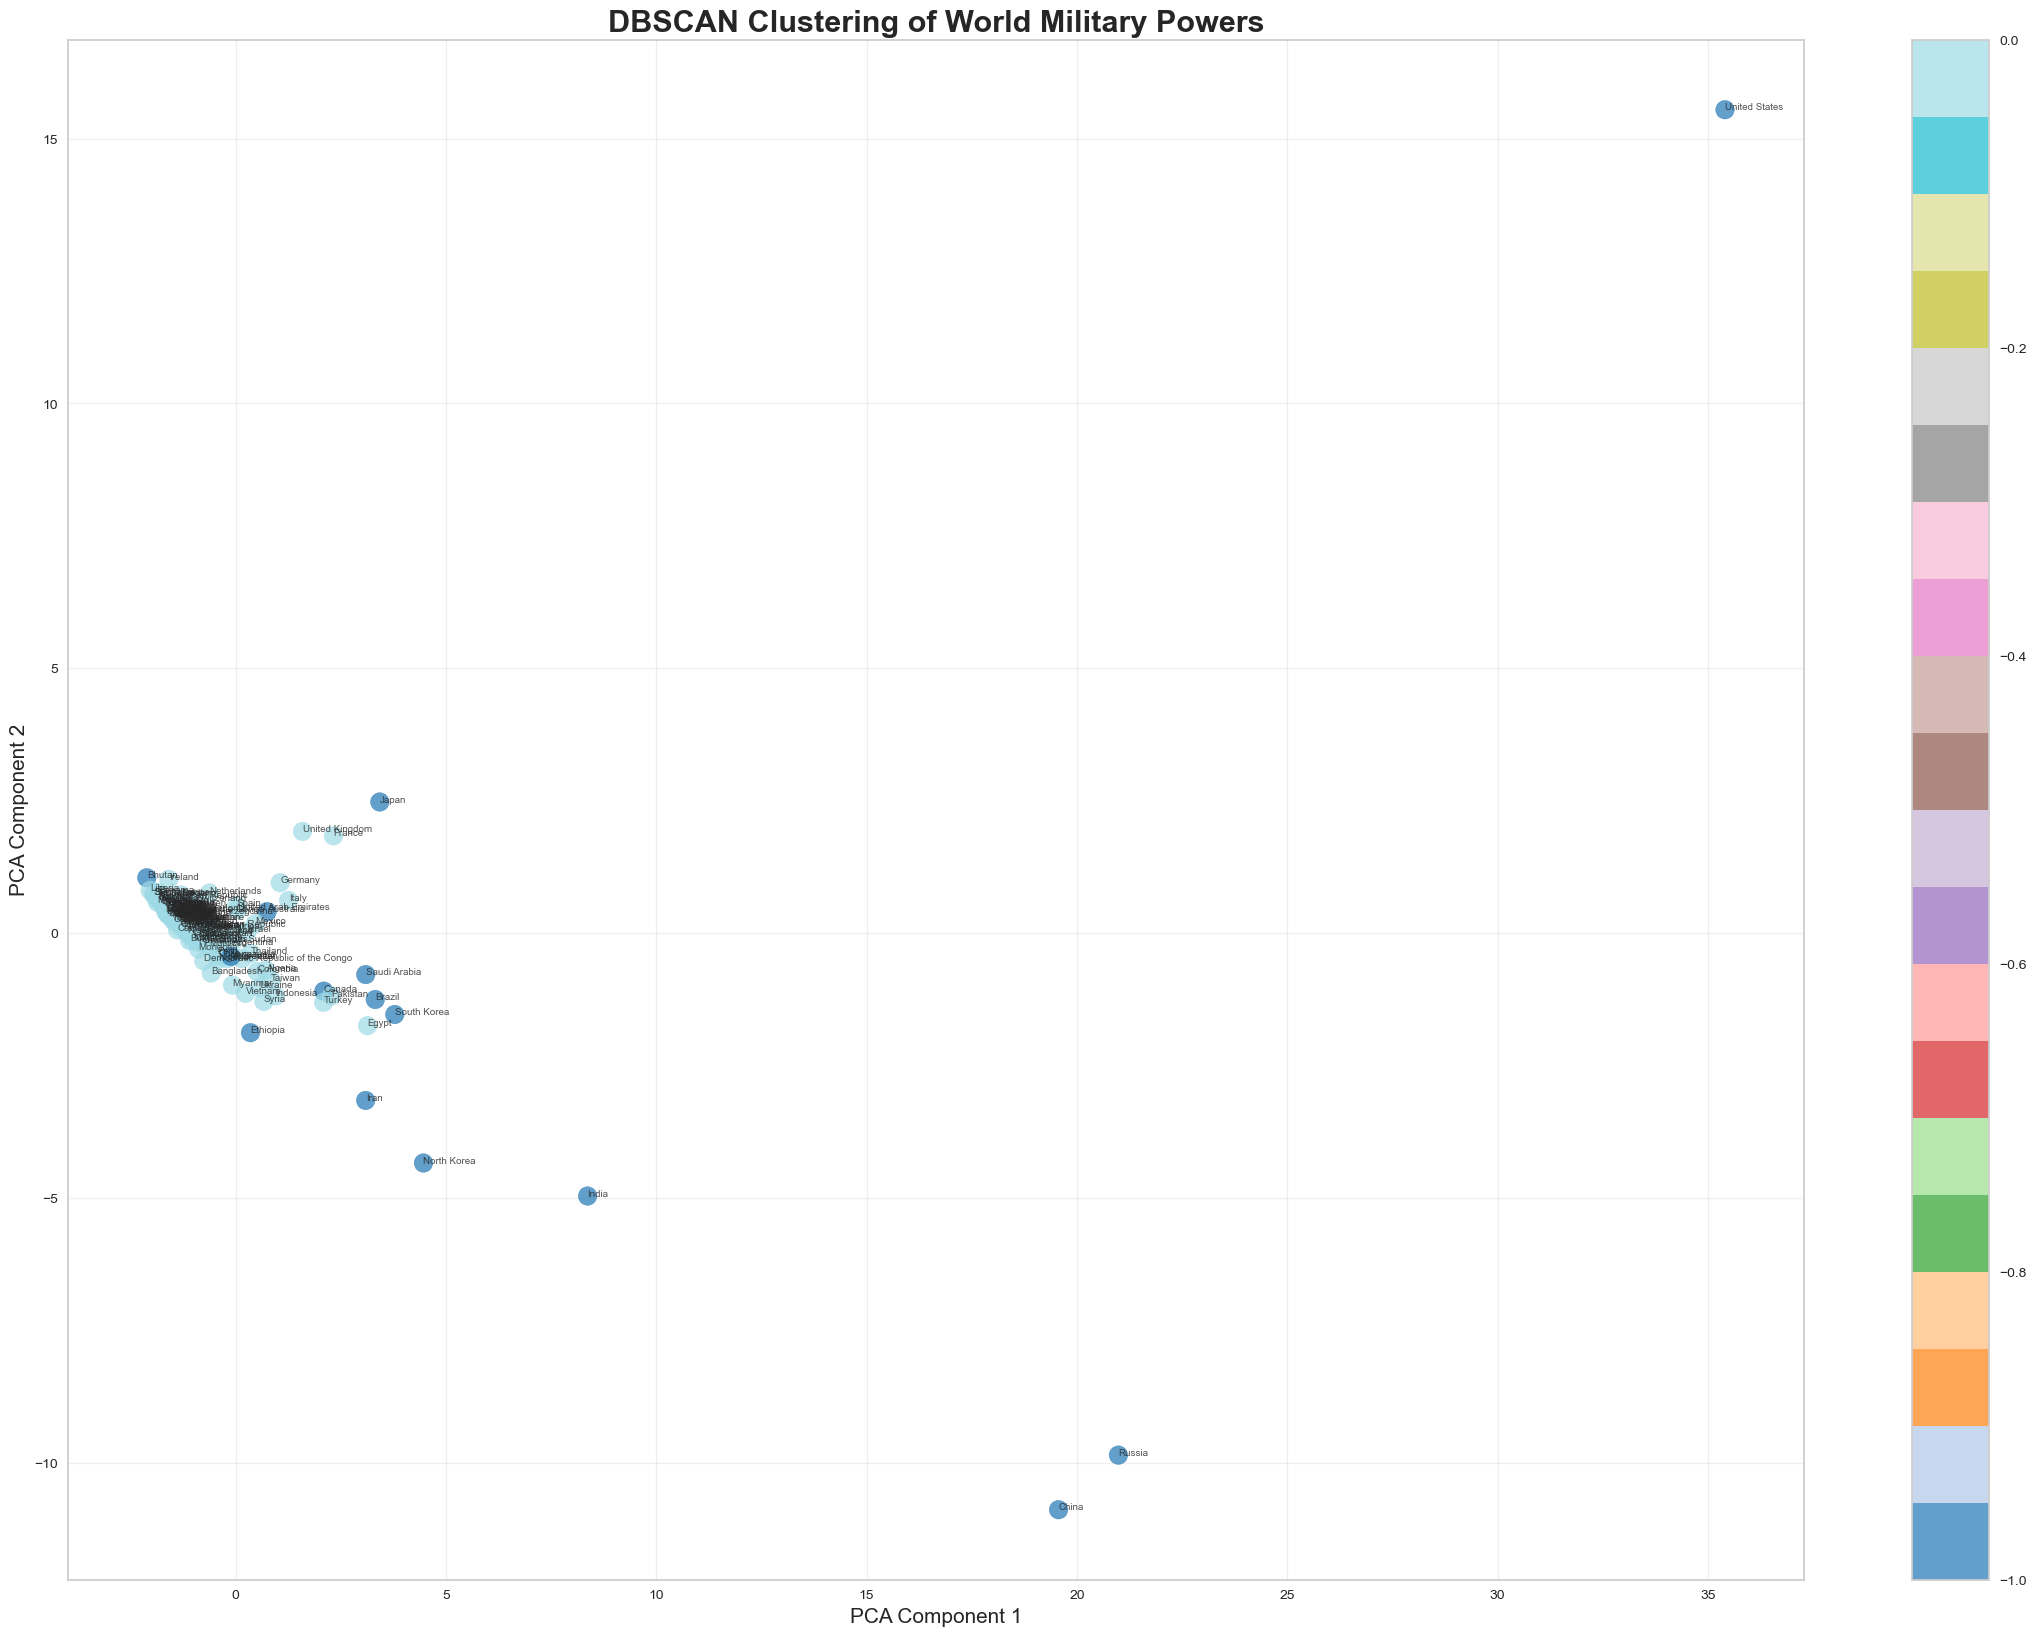

In [71]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Veri
X = clean_df.drop(
    ["Country", "Cluster", "Power_Level",
     "HC_Cluster", "DBSCAN_Cluster"],
    axis=1,
    errors="ignore")

# Scaling
x2 = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(
    eps=3.5,
    min_samples=3)

y = db.fit_predict(x2)

clean_df["DBSCAN_Cluster"] = y

# PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(x2)

# Grafik
plt.figure(figsize=(28,20))

scatter = plt.scatter(
    pca_components[:,0],
    pca_components[:,1],
    c=y,
    cmap="tab20",
    s=180,
    alpha=0.7)

# TÜM ülkeler
for i, country in enumerate(clean_df["Country"]):

    plt.annotate(country,
        ( pca_components[i,0],
            pca_components[i,1]),fontsize=7,alpha=0.8)

plt.title("DBSCAN Clustering of World Military Powers",
    fontsize=22,
    fontweight="bold")

plt.xlabel("PCA Component 1", fontsize=15)
plt.ylabel("PCA Component 2", fontsize=15)

plt.grid(alpha=0.3)

plt.colorbar(scatter)

plt.show()

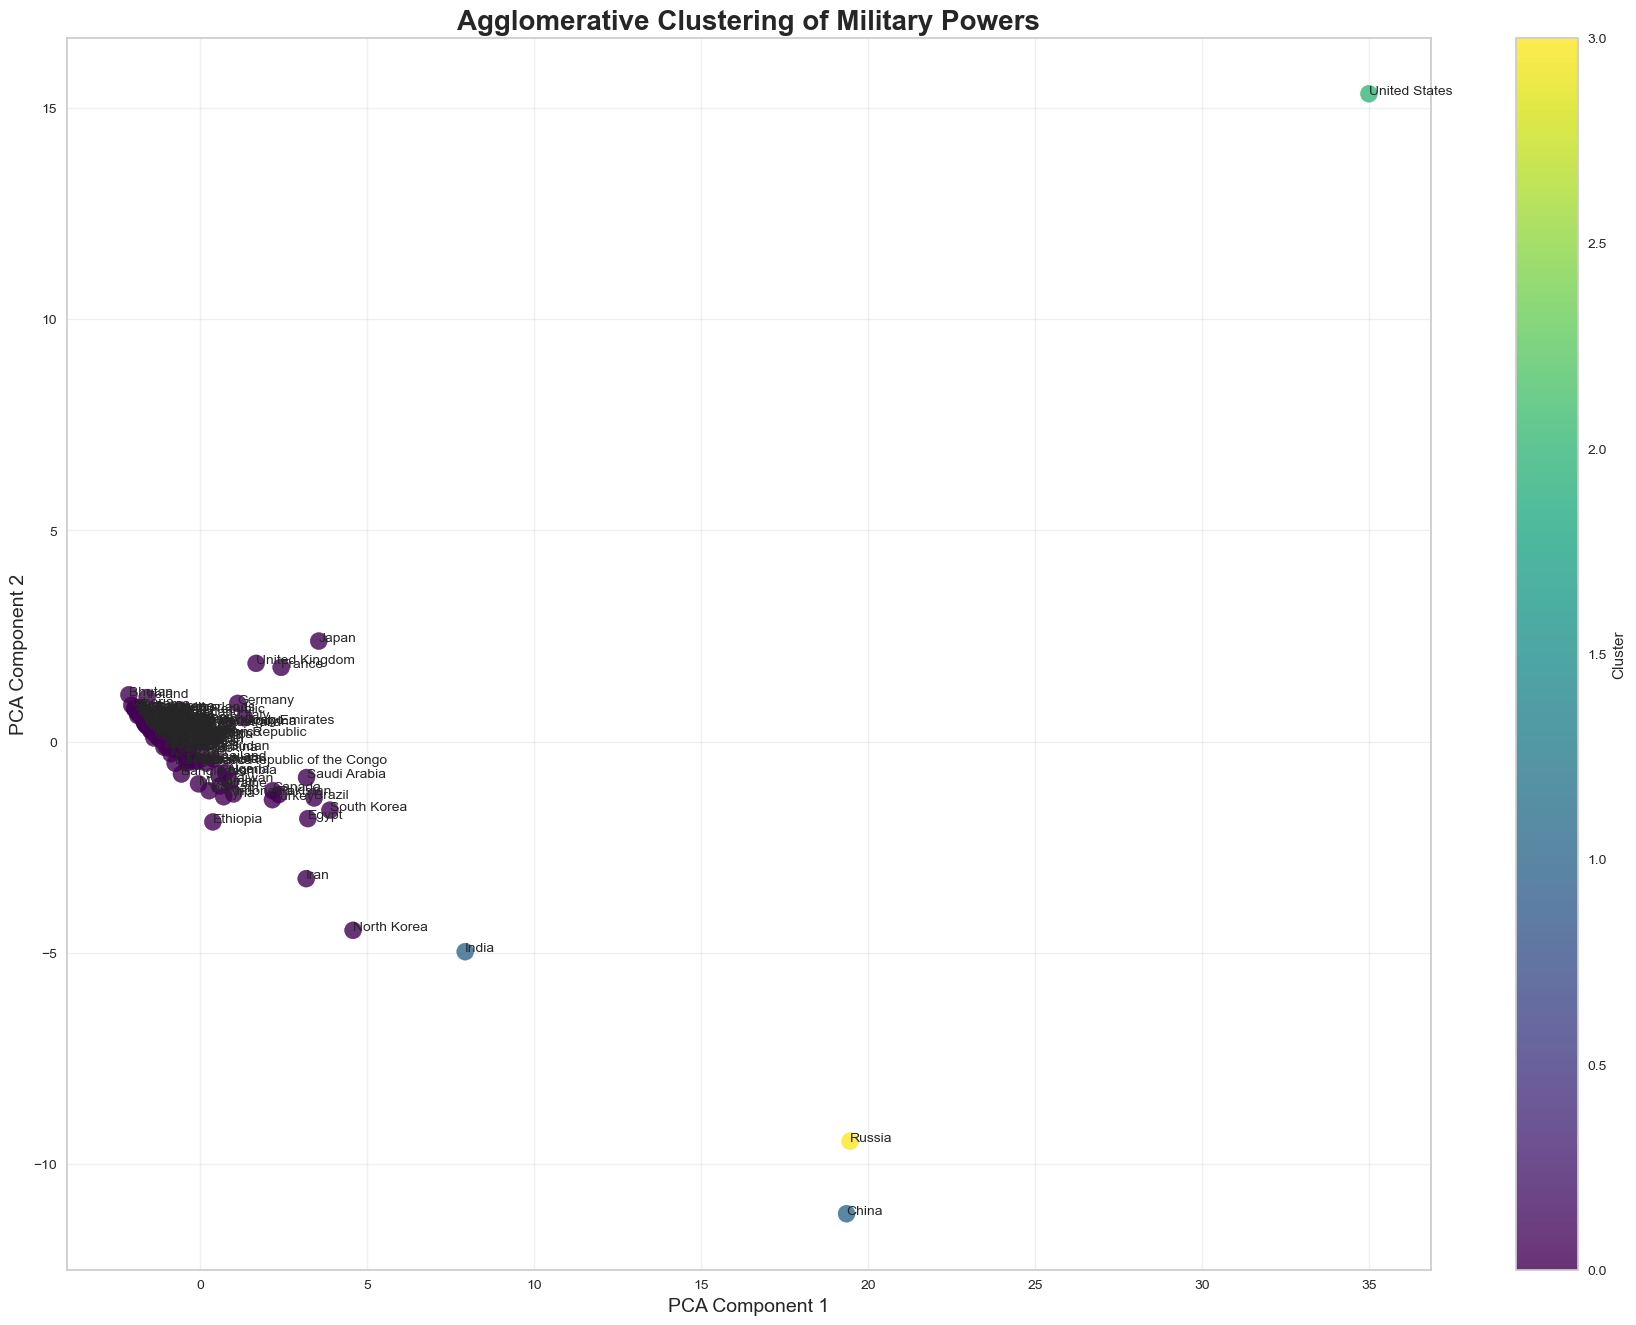

In [72]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Veri
X = clean_df.drop(
    ["Country", "Cluster", "Power_Level",
     "HC_Cluster", "DBSCAN_Cluster", "Agg_Cluster"],
    axis=1,
    errors="ignore")

X = X.fillna(X.mean())

# Scaling
x_scaled = StandardScaler().fit_transform(X)

# Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=4)

y_agg = agg_clustering.fit_predict(x_scaled)

clean_df["Agg_Cluster"] = y_agg

# PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

# Grafik
plt.figure(figsize=(22,16))

scatter = plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=y_agg,
    s=150,
    cmap="viridis",
    alpha=0.8)

# TÜM ülke isimleri
for i, country in enumerate(clean_df["Country"]):

    plt.annotate(
        country,
        (  x_pca[i,0],
            x_pca[i,1]),
        fontsize=10)

plt.title(
    "Agglomerative Clustering of Military Powers",
    fontsize=20,
    fontweight="bold")

plt.xlabel("PCA Component 1", fontsize=14)
plt.ylabel("PCA Component 2", fontsize=14)

plt.grid(alpha=0.3)

plt.colorbar(scatter, label="Cluster")

plt.show()

#### In this project, I learned:
- Data preprocessing and cleaning
- Feature scaling
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN
- Elbow Method
- Silhouette Score
- PCA visualization
- Cluster interpretation and analysis

### As a result, clustering algorithms successfully grouped countries according to their military power characteristics. The analysis revealed meaningful differences between super powers, regional military powers, and lower-capacity countries. K-Means, Hierarchical Clustering, and DBSCAN methods provided different perspectives for understanding the structure of global military power data. This project demonstrated the effectiveness of unsupervised machine learning techniques in analyzing complex real-world datasets.